# Fraud Detection — Model Training

Orchestrates the full Layer 2 pipeline:
`load → feature engineering → prep → split → select → tune → train → evaluate → save`

All logic lives in `src/features.py` and `src/model.py`.
This notebook is for running and observing, not for defining functions.

In [1]:
import sys
sys.path.append('..')   # so 'src' is importable from notebooks/

import mlflow
from pathlib import Path
import mlflow.lightgbm
import pandas as pd
import lightgbm as lgb
from src.features import build_features
from src.model import (
    prepare_features,
    time_based_split,
    select_features,
    tune_hyperparameters,
    train,
    evaluate,
    plot_feature_importance,
    save_model,
    LABEL,
)

DATA_DIR = '../data'
import src as _src
MLRUNS = str(Path(_src.__file__).parent.parent / "mlruns")
mlflow.set_tracking_uri(MLRUNS)  # anchored to src/ — works regardless of kernel CWD
mlflow.set_experiment('fraud-detection')

<Experiment: artifact_location='file:///Users/sonje/Desktop/Rohit/Old%20Desktop/Python/fraud-detection/mlruns/406551328193655437', creation_time=1779566767740, experiment_id='406551328193655437', last_update_time=1779566767740, lifecycle_stage='active', name='fraud-detection', tags={}>

## 1. Load raw data

In [2]:
trn = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
idn = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
print(f'Transactions : {trn.shape}')
print(f'Identity     : {idn.shape}')

Transactions : (590540, 394)
Identity     : (144233, 41)


## 2. Feature engineering

In [3]:
df = build_features(trn, idn)
print(f'After feature engineering: {df.shape}')

Merged            : 590,540 rows × 434 cols
Identity coverage : 24.4%
After feature engineering: (590540, 450)


## 3. Prepare feature matrix

In [4]:
df = prepare_features(df)
print(f'After prep: {df.shape}')

Dropping 9 columns with >99% missing
After prep: (590540, 439)


## 4. Time-based split

In [5]:
train_df, test_df = time_based_split(df)

FEATURES = [c for c in train_df.columns if c != LABEL]
X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_test,  y_test  = test_df[FEATURES],  test_df[LABEL]

print(f'Train : {X_train.shape}  |  fraud rate: {y_train.mean():.2%}')
print(f'Test  : {X_test.shape}   |  fraud rate: {y_test.mean():.2%}')

Train : (472432, 438)  |  fraud rate: 3.51%
Test  : (118108, 438)   |  fraud rate: 3.44%


## 5. Feature selection

Trains a fast baseline LightGBM internally, then uses `SelectFromModel`
to keep only features with importance >= mean importance.
More principled than keeping any feature with non-zero importance.

In [6]:
X_train_f, X_test_f, features_f = select_features(
    X_train, y_train, X_test, threshold='median'
)

Features kept   : 237 / 438
Features dropped: 201


## 6. Hyperparameter tuning

In [7]:
best_params = tune_hyperparameters(X_train_f, y_train, n_trials=50)

  0%|          | 0/50 [00:00<?, ?it/s]

Best PR-AUC : 0.5693
Best params : {'num_leaves': 283, 'learning_rate': 0.10824924903804756, 'max_depth': 12, 'min_child_samples': 122, 'feature_fraction': 0.8325873147129733, 'bagging_fraction': 0.7222551395260963, 'lambda_l1': 2.9611844429832927e-05, 'lambda_l2': 0.004563321949249074}


## 7. Train final model + log with MLflow

PR-AUC  : 0.3755
ROC-AUC : 0.8322


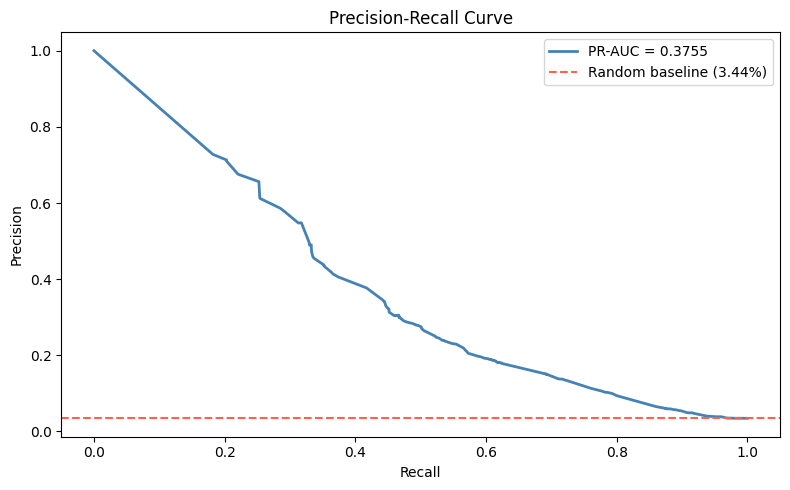

2026/05/27 19:01:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 19:01:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



MLflow run logged. PR-AUC: 0.3755


In [8]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

with mlflow.start_run(run_name='lgbm-selectfrommodel-median'):

    mlflow.log_params({
        'train_rows':       len(X_train_f),
        'test_rows':        len(X_test_f),
        'n_features':       X_train_f.shape[1],
        'fraud_rate_train': round(float(y_train.mean()), 4),
        'identity_merged':  True,
        'missing_threshold': 0.99,
        'feature_selection': 'SelectFromModel(median)',
    })
    mlflow.log_params(best_params)

    model_tuned = lgb.LGBMClassifier(
        **best_params,
        scale_pos_weight=neg / pos,
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
    )
    model_tuned.fit(
        X_train_f, y_train,
        eval_set=[(X_test_f, y_test)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(100),
        ],
    )

    metrics = evaluate(model_tuned, X_test_f, y_test, plot=True)
    mlflow.log_metrics(metrics)
    mlflow.lightgbm.log_model(model_tuned, artifact_path='model')

    print(f"\nMLflow run logged. PR-AUC: {metrics['pr_auc']:.4f}")

## 8. Feature importance

         feature  importance
   TransactionDT          19
             C11          18
   hist_mean_amt          16
              D2          10
   amt_deviation          10
             D15          10
 card_unique_amt           9
             C14           7
           card1           6
            V310           6
     velocity_7d           5
           id_02           5
           card5           5
              C5           5
              D4           4
              D8           4
             D10           4
              D1           4
card_unique_addr           4
             V61           3


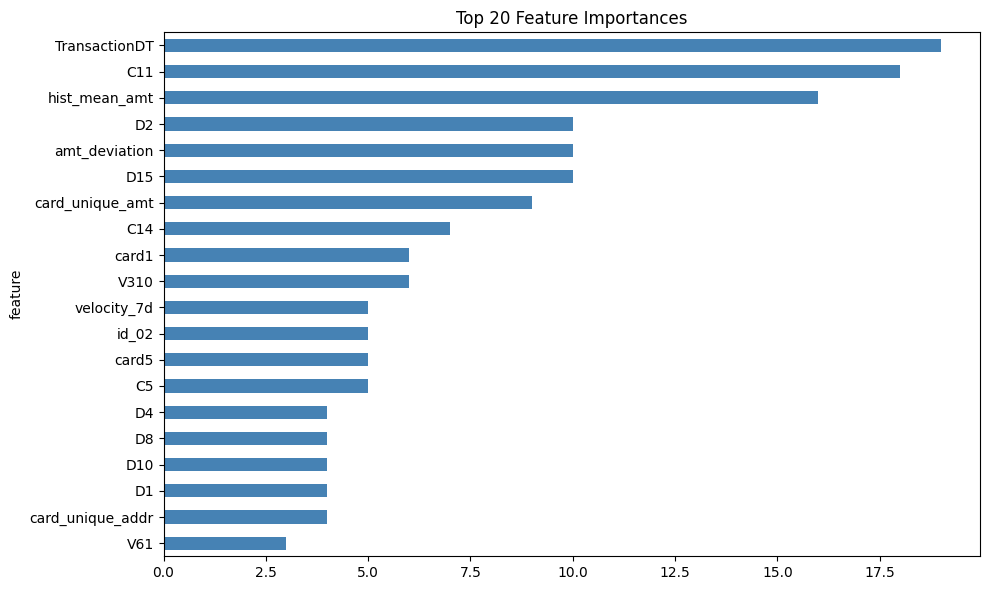

In [9]:
plot_feature_importance(model_tuned, features_f)

## 9. Save model to disk

In [10]:
cat_features = X_train_f.select_dtypes(include='category').columns.tolist()
print(f'Categorical features: {len(cat_features)}')
save_model(model_tuned, cat_features)

Categorical features: 19
Model saved to /Users/sonje/Desktop/Rohit/Old Desktop/Python/fraud-detection/notebooks/../models/lgbm_fraud.pkl  (19 categorical features)


## 10. View MLflow UI

```bash
mlflow ui
```
Open http://localhost:5000 to compare all runs side by side.